In [1]:
import cv2
import os
import glob
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sbn

In [4]:
cat_files = glob.glob("./Cat/*.jpg")
dog_files = glob.glob("./Dog/*.jpg")

In [5]:
sample_cat = cv2.imread(cat_files[1])

In [6]:
sample_cat.shape

(281, 300, 3)

### Affichez avec OpenCV

**Remarque :** pour quitter la fenêtre, il suffit d'appuyer sur la touche "Q" 

In [7]:
# TODO
cv2.imshow("Image chat", sample_cat)
cv2.waitKey(0)
cv2.destroyAllWindows()

### Affichez avec matplotlib

$\Rightarrow$ pensez à convertir en RGB car par défaut,  OpenCV importe en BGR !

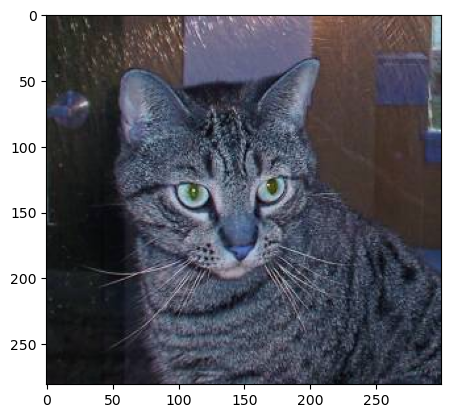

In [10]:
# TODO
plt.imshow(sample_cat)

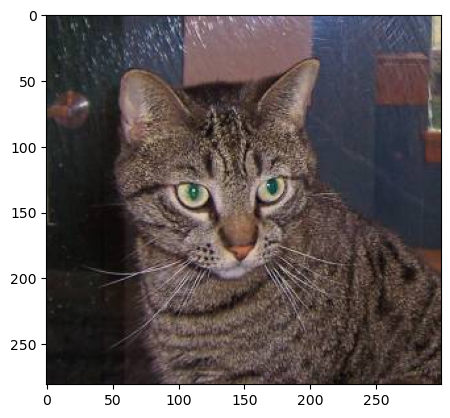

In [13]:
rgb_cat = cv2.cvtColor(sample_cat, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_cat)


### Enregistrez l'image dans un fichier `test_image_save.png` situé dans le dossier `./data/cat_dog`

In [ ]:
# TODO

### Quelques information sur l'image `sample_cat`

#### Affichez la hauteur, la largeur et le nombre de canaux de l'image 
Conséquence : il est plus rapide à lire en ligne qu'en colonne

In [ ]:
# TODO

#### Affichez le nombre de valeurs

In [ ]:
# TODO

#### Affichez la valeur du pixel (0,0)

In [ ]:
# TODO

#### Affichez la valeur du canal vert (G) du pixel (0,0)

In [ ]:
# TODO

#### Application 1 : affichez uniquement la composante rouge de l'image

$\Rightarrow$ si vous vous souvenez du cours sur Pyplot, choisissez une [Colormap adaptée](https://matplotlib.org/stable/users/explain/colors/colormaps.html) 

In [ ]:
# TODO

#### Application 2 : éclaircissez l'image en ajoutant 100 comme valeur à chaque canal

In [ ]:
rgb_cat2 = rgb_cat.copy()
# TODO
plt.imshow(rgb_cat2)

Que s'est-t-il passé ? Corrigez le problème !

In [ ]:
rgb_cat2 = rgb_cat.copy()
# TODO
plt.imshow(rgb_cat2, vmin=0, vmax=255)

Comme souvent, OpenCV possède des [méthodes dédiées](https://docs.opencv.org/3.4/d2/de8/group__core__array.html#ga3460e9c9f37b563ab9dd550c4d8c4e7d). Faites la modification.

In [ ]:
rgb_cat_2 = # TODO
plt.imshow(rgb_cat_2, vmin=0, vmax=255)

Dans le code ci-dessus, `alpha` est un coefficient multiplicatif et  `beta` est un coefficient additif, plus précisément, la nouvelle valeur de pixel se calcule via la façon suivante : $\min(255, \max(0, p*\alpha+\beta))$.

Comment assombrir l'image ?

In [ ]:
rgb_cat_2 = # TODO
plt.imshow(rgb_cat_2, vmin=0, vmax=255)

#### Calcul d'une lookup table

In [ ]:
lookUpTable = np.empty((1, 256), np.uint8)

def adjust_gamma(image, gamma=1.0):
    for i in range(256):
        lookUpTable[0, i] = np.clip(pow(i / 255.0, gamma) * 255.0, 0, 255)
    return cv2.LUT(image, lookUpTable)
    
rgb_cat_2 = adjust_gamma(rgb_cat, 0.5)
plt.imshow(rgb_cat_2, vmin=0, vmax=255)

Dans l'exemple ci-dessus, `gamma` est non linéaire : soit $p$ la valeur normalisée (entre 0 et 1) d'un pixel, la correction $\gamma$ s'obtient en calculant $max(0, min(p^\gamma \times 255, 255))$.

Concernant sa valeur :
- Si $\gamma=1$, l'image reste inchangée (pas de correction).
- Si $\gamma > 1$, les valeurs de l'image (notamment les tons moyens) seront atténuées et tirées vers le bas, ce qui rend l'image plus sombre.
- Si $\gamma < 1$, les valeurs de l'image (notamment les tons sombres et moyens) seront amplifiées et rehaussées, ce qui rend l'image plus claire.

**Remarques :**
- `np.clip(array, min, max)` : toutes les valeurs du tableau `array` restent dans l'intervalle `[min, max]`.
- `cv2.LUT` : permet d'appliquer une table de correspondance (*lookup table* ou LUT). Cela permet d'accélérer le temps de calcul en évitant de devoir recalculer pour chaque pixel la nouvelle valeur car il suffit simplement de lire dans cette table.

In [ ]:
plt.plot(range(0,256), lookUpTable[0])
plt.plot(range(0,256), [i for i in range(256)])
plt.title('Correspondance de valeurs du coefficient choisi')
plt.show()

Comment lire ce graphe ?

- valeurs plus près du blanc
- plage de valeurs des couleurs claires augmentée, mais très sombres réduite

### Manipulation d'images avec OpenCV et Numpy

"Clippez" l'image pour ne garder que des valeurs comprises entre 100 et 200 pour chaque canal.

In [ ]:
# TODO

Clippez l'image, mais en remplaçant les valeurs de chaque canal qui ne sont pas dans l'intervalle [100, 200] par 255. Par exemple, si le pixel $p$ a comme couleur $(230, 150, 18)$, sa nouvelle couleur doit être $(255, 150, 255)$.

In [ ]:
rgb_cat2 = rgb_cat.copy()
# TODO
plt.imshow(rgb_cat2)

Convertissez votre image en niveau de gris à l'aide d'OpenCV.

In [ ]:
grey_cat = # TODO
plt.imshow(grey_cat, cmap='gray')

En utilisant une fonction OpenCV, modifiez l'image en niveau de gris obtenue ci-dessus de telle sorte que chaque pixel en dessous d'un seuil prenne la valeur 0, et chaque pixel au dessus de ce seuil la valeur 255. Testez avec 100 comme valeur de seuil.

In [ ]:
_, threshold_cat = # TODO
plt.imshow(threshold_cat, cmap='gray', vmin=0, vmax=255)

Croppez l'image pour ne garder que les lignes d'indices 100 à 199 (inclus).

In [ ]:
plt.imshow(# TODO)

Croppez l'image pour ne garder que les lignes *et* que les colonnes dont l'indice est compris entre 100 et 199 (inclus).

In [ ]:
plt.imshow(# TODO])

Lissez votre image en ajoutant du flou à l'aide de la méthode `cv2.blur`. Testez avec différentes tailles de noyau (*kernel*)

In [ ]:
plt.imshow(# TODO)

In [ ]:
plt.imshow(# TODO)

### Rotation d'image

Effectuez une rotation sur l'image à l'aide des méthodes d'OpenCV. Pour cela, vous devez :
1. Récuperez la matrice de rotation à l'aide de la méthode `cv2.getRotationMatrix2D`.
2. Appliquer la rotation à l'aide de la méthode `cv2.warpAffine`.

In [ ]:
(h, w, _) = rgb_cat.shape
center = 100, 100
angle = 60
scale = 2
rotation_matrix = # TODO
rotated = # TODO
plt.imshow(rotated)

### Translation d'image

Pour appliquer une translation de $tx$ sur l'axe des $x$ et $ty$ sur l'axe des $y$, il faut créer la matrice de translation $
T = \begin{pmatrix}
1 & 0 & tx \\
0 & 1 & ty
\end{pmatrix}$ où :

* les $1$ indiquent que l'on souhaite conserver les coordonnées $x$ et $y$ (elles ne sont pas multipliées par un facteur de mise à l'échelle)
* les $0$ indiquent l'indépendance entre les axes des abscisses et des ordonnées.

Appliquez une translation avec $tx=70$ et $ty=110$.

In [ ]:
translation_matrix = np.float32([# TODO])
translated = # TODO
plt.imshow(translated)

Et sans cropper ?

In [ ]:
translated = cv2.warpAffine(rgb_cat, translation_matrix, (w+70, h+110))
plt.imshow(translated)

### Redimensionnement d'images

Si on souhaite augmenter la taille d'une image (méthode `cv2.resize`), il faut donc créer de nouveaux pixels par interpolation à partir des pixels existants. Pour cela, plusieurs méthodes existent et sont implémentées dans OpenCV :

* `INTER_NEAREST` : le nouveau pixel récupère la couleur du pixel le plus proche dans l'image initiale.
* `INTER_LINEAR` : interpolation bilinéaire par utilisation des pixels voisins.
* `INTER_BICUBIC` : interpolation bicubique.
  
<img src="img/interpolation_from_wikipedia.png" alt="interpolation_wikipedia" style="width: 60%;"/>
&copy; Wikipédia

Voir [ce cours](https://perso.esiee.fr/~perretb/I5FM/TAI/geometry/index.html#interpolation-2d) sur les transformations géométriques.

>"Dans ces illustrations, les valeurs des fonctions aux points rouges, jaunes, verts et bleus sont connues. Le but est de déterminer la valeur interpolée au niveau du point noir. Les courbes grises représentent les courbes interpolées.
>* L’interpolation par plus proche voisin consiste à utiliser la valeur du point connu le plus proche.
>* L’interpolation linéaire consiste à tracer des droites entre les points connus les plus proches : en 1D il faut 2 points, en 2D il en faut 4.
>* L’interpolation cubique consiste à tracer des polynomes de degré 3 entre les points connus les plus proches : en 1D il faut 4 points, en 2D il en faut 16.
>"

Doublez la taille de l'image `rgb_cat` en testant l'interpolation par plus proche voisin et l'interpoplation cubique.

In [ ]:
plt.figure(figsize=(20, 10))
resized = # TODO
resized2 = # TODO
plt.subplot(1, 2, 1)
plt.imshow(resized)
plt.title("Interpolation nearest neighbour")
plt.subplot(1, 2, 2)
plt.imshow(resized2)
plt.title("Interpolation cubique")
plt.show()

Appliquons les mêmes méthodes de redimensionnement et zoomons sur l'image pour mieux voir les différences.

In [ ]:
plt.figure(figsize=(20, 10))
resized = # TODO
resized2 = # TODO
plt.subplot(1, 2, 1)
plt.imshow(resized)
plt.title("Interpolation nearest neighbour")
plt.xlim(200, 300)
plt.ylim(400, 200)
plt.subplot(1, 2, 2)
plt.xlim(200, 300)
plt.ylim(400, 200)
plt.imshow(resized2)
plt.title("Interpolation cubique")
plt.show()

# Ajouter des informations à une image

### Tracez des formes 

Tracez un rectangle.

In [ ]:
top_left_corner = (100, 120)
bottom_right_corner = (190, 200)
color =  (0, 255, 255)
thickness = 5 # -1 pour fill
rgb_cat2 = # TODO
plt.imshow(rgb_cat2)

Tracez un cercle.

In [ ]:
center = (150, 180)
radius = 8
color = (255, 0, 0)
thickness = -1
rgb_cat2 = # TODO
plt.imshow(rgb_cat2)

Tracez une ligne droite.

In [ ]:
begin = (145, 190)
end = (200, 300)
thickness = 5
rgb_cat2 = # TODO
plt.imshow(rgb_cat2)

Ajoutez du texte à l'image.

In [ ]:
origin = (50, 50)
font = cv2.FONT_HERSHEY_SIMPLEX 
fontscale = 2
thickness = 5
color = (0, 0, 255)
rgb_cat2 = # TODO 
plt.imshow(rgb_cat2)

# Traitement d'image 

Comment améliorer l'extraction du fond ?

In [ ]:
_, threshold_cat = cv2.threshold(grey_cat, 70, 220, cv2.THRESH_BINARY_INV)
plt.imshow(threshold_cat, cmap='gray', vmin=0, vmax=255)

#### Solution 1 : améliorer le threshold avec `cv2.adaptiveThreshold`. Ici, l'idée est de ne pas utiliser un unique seuil global mais d'avoir des valeurs de seuil qui varient localement.

In [ ]:
threshold_cat = # TODO
plt.imshow(threshold_cat, cmap='gray', vmin=0, vmax=255)

#### Solution 2 : effectuer des traitements supplémentaires pour améliorer le seuil.

La dilatation et l'érosion sont deux opérations morphologiques opposées utilisées en traitement d'image afin de respectivement augmenter ou diminuer la taille des objets présents dans une image. Le principe est simple et repose dans les deux cas sur l'utilisation d'éléments structurants. Ces derniers généralisent le concept de *kernel* vu précédemment dans le sens où ils peuvent décrire des formes plus complexes que seulement des rectangles : il peut s'agir de cercles, triangles, croix etc.

Pour chaque pixel $p$ d'une image binarisée (ou en niveau de gris), on note $val(p)$ la valeur du pixel $p$. La superposition de l'élément structurant à $p$ permet de définir un groupe de pixels "actifs", disons $X$. La nouvelle valeur $val(p)$ du pixel $p$ vaut :

* $val(p) = \max_{q \in X} val(q)$, c'est-à-dire la plus grande valeur parmi tous les pixels actifs dans le cadre d'une dilatation,
* $val(p) = \min_{q \in X} val(q)$, c'est-à-dire la plus petite valeur parmi tous les pixels actifs dans le cadre d'une érosion.

Faisons une dilation de l'image `grey_cat` à l'aide de `cv2.dilate`. Nous commençons par la binariser à l'aide de `cv2.adaptiveThreshold`.

In [ ]:
kernel = np.ones((5,5), np.uint8)

threshold_cat = cv2.adaptiveThreshold(grey_cat, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 5, 10)
dilated = # TODO

plt.imshow(dilated,cmap='gray', vmin=0, vmax=255)

On enchaîne avec une érosion à l'aide de la méthode `cv2.erode`.

In [ ]:
eroded = # TODO
plt.imshow(eroded,cmap='gray', vmin=0, vmax=255)

Comment obtenir le résultat final pour extraire le fond ? Indice : on peut utiliser l'image `eroded` comme un masque...

In [ ]:
result = # TODO
plt.imshow(result,cmap='gray', vmin=0, vmax=255)

Il est possible d'enchaîner ces deux opérations en une ligne : 
- ouverture (*opening*) qui consiste en une érosion suivie d'une dilatation,
- fermeture (*closing*) qui consiste en une dilatation suivie d'une érosion.

Cependant, cela nous laisse moins de libertés car le nombre d'itérations pour la dilatation et l'érosion doit être le même.

In [ ]:
threshold_cat_copy = cv2.adaptiveThreshold(grey_cat, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 5, 10)
threshold_cat_copy = cv2.morphologyEx(threshold_cat_copy, cv2.MORPH_CLOSE, kernel)

plt.imshow(threshold_cat_copy, cmap='gray', vmin=0, vmax=255)
plt.show()
result = cv2.bitwise_and(threshold_cat_copy, grey_cat)
plt.imshow(result, cmap='gray', vmin=0, vmax=255)

# Extraction de contours

La méthode `cv2.Canny` permet de détecter les contours d'une image. L'algorithme procède en plusieurs étpaes :
1. Réduction de bruit (par floutage) afin de ne pas fausser la détection des contours car celle-ci se concentre sur les variations d'intensité lumineuses.
2. Calcul du gradient pour détecter les zones où il y a des changements d'intensité importants.
3. Suppression non maximum : on ne garde que les pixels représentant des maximums locaux dans la direction du gradient afin de réduire le nombre de "faux" contours.
4. Seuils d'hystérésis. Cette étape permet de déterminer les "vrais" contours. Pour cela, on utilise deux valeurs de seuil $tmin$ et $tmax$ :
    - les contours dont le seuil d'intensité du gradient est inférieur à $tmin$ sont éliminés, 
    - les contours dont le seuil d'intensité du gradient est supérieur à $tmax$ sont conservés, 
    - les contours dont le seuil d'intensité du gradient est compris entre ces deux valeurs sont conservés uniquement s'ils sont "rattachés" à un contour dont le gradient est supérieur à $tmax$.

In [ ]:
tmin = 50
tmax = 300
edges = # TODO
plt.imshow(edges,cmap='gray', vmin=0, vmax=255)

Pour des contours clos, on peut utiliser les méthodes `cv2.findContours` et `cv2.drawContours`.

In [ ]:
grey_cat2 = grey_cat.copy()
# TODO
mask = np.zeros(grey_cat2.shape[:2], np.uint8)
# TODO
plt.imshow(mask,cmap='gray', vmin=0, vmax=255)

In [ ]:
result = cv2.bitwise_and(mask,grey_cat)
plt.imshow(result, cmap='gray', vmin=0, vmax=255)

L'objet `contours` renvoyé par `cv2.findContours` est en fait une liste de contours. On peut également récupérer la hiérarchie entre les éventuels contours (e.g., contour inclus dans un autre) en indiquant `cv2.RETR_TREE` comme valeur du paramètre `mode`.

OpenCV fournit également des [méthodes automatiques](https://docs.opencv.org/4.x/dd/d49/tutorial_py_contour_features.html) pour obtenir des informations sur chaque contour :

In [ ]:
non_empty_areas = [cv2.contourArea(contour) for contour in contours] 

In [ ]:
print(f'Notre plus gros contours : {non_empty_areas[np.argmax(areas)]}')

À l'aide de la méthode `cv2.fillPoly` et du plus gros contour, faites l'extraction de l'arrière-plan comme précédemment.

In [ ]:
mask = np.zeros(grey_cat2.shape[:2], np.uint8)
# TODO
result = cv2.bitwise_and(mask, grey_cat)
plt.imshow(result, cmap='gray', vmin=0, vmax=255)

La méthode `cv2.rectangle` permet de dessiner des rectangles sur une image, ce qui permet par exemple de tracer la boîte englobante d'un objet détecté.

In [ ]:
x, y, w, h = cv2.boundingRect(mask)
result = # TODO
plt.imshow(result,cmap='gray', vmin=0, vmax=255)

### Histogramme d'une image

L'histogramme d'une image est la représentation graphique de la distribution des pixels d'une image. L'histogramme est donc une fonction $f$ qui associe à chaque valeur possible pour un pixel le nombre de pixels de l'image ayant cette valeur. Par exemple, dans le cadre d'une image en niveau de gris (avec un seul canal) codée sur 8 bits, chaque pixel peut prendre une valeur comprise entre $0$ et $255$. Ainsi, sur l'axe des abscisses, nous aurons ces 256 valeurs possibles. La valeur de $f$ en $i$ (avec $0 \le i \le 255$) correspond au nombre total de pixels de l'image dont le niveau de gris vaut précisément $i$. 

Calculez l'histogramme de l'image `grey_cat` sans utiliser OpenCV. Vous pouvez utiliser la fonction `sbn.displot`, notamment avec l'option `discrete=True`.

In [ ]:
# TODO
plt.title("Repartition des couleurs dans l'image")
plt.show()

Dans le cadre d'une image RGB, OpenCV est plus simple si on souhaite réaliser un histogramme par canal de couleur. Calculez l'histogramme de chaque couleur de l'image `sample_cat`.

In [ ]:
color = ('b', 'g', 'r')

for i,col in enumerate(color):
    hist = # TODO
    plt.plot(hist, color = col)
    plt.xlim([0, 256])

plt.show()

# TD d'application

Répondez aux deux questions suivantes :

1. À partir des données fournies (`cat_files` et `dog_files`), pouvez vous utiliser certaines couleurs pour faire la différence entre chat et chien ?
2. Sur ces mêmes données, pouvez vous utiliser la taille de l'animal à l'image (par exemple aire du contours) pour faire la différence entre chat et chien ?

In [ ]:
# TODO